# San Antonio Capital Improvement Program (CIP) — Exploratory Analysis

**Data:** Scraped from 27 adopted budget PDFs (FY 2008–2026) via `src/scrape_cip.py`

Three datasets:
- `cip_categories.csv` — annual CIP spending by program category (Streets, Parks, Air Transportation, etc.)
- `cip_revenue_sources.csv` — how capital spending is funded (G.O. Bonds, Certificates of Obligation, etc.)
- `bond_status.csv` — voter-approved bond authorizations vs. debt issued vs. remaining capacity

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

cat = pd.read_csv('../data/processed/cip_categories.csv')
rev = pd.read_csv('../data/processed/cip_revenue_sources.csv')
bonds = pd.read_csv('../data/processed/bond_status.csv')

print(f'CIP Categories: {len(cat)} rows, FY{cat.fiscal_year.min()}–{cat.fiscal_year.max()}')
print(f'Revenue Sources: {len(rev)} rows, FY{rev.fiscal_year.min()}–{rev.fiscal_year.max()}')
print(f'Bond Status:     {len(bonds)} rows, FY{bonds.fiscal_year.min()}–{bonds.fiscal_year.max()}')

CIP Categories: 193 rows, FY2008–2026
Revenue Sources: 89 rows, FY2011–2026
Bond Status:     76 rows, FY2015–2026


## How Big Is San Antonio's Capital Program?

The annual CIP budget is the city's plan for *building things* — streets, parks, airport terminals,
drainage, fire stations, libraries. This is separate from the operating budget (salaries, services, etc.).

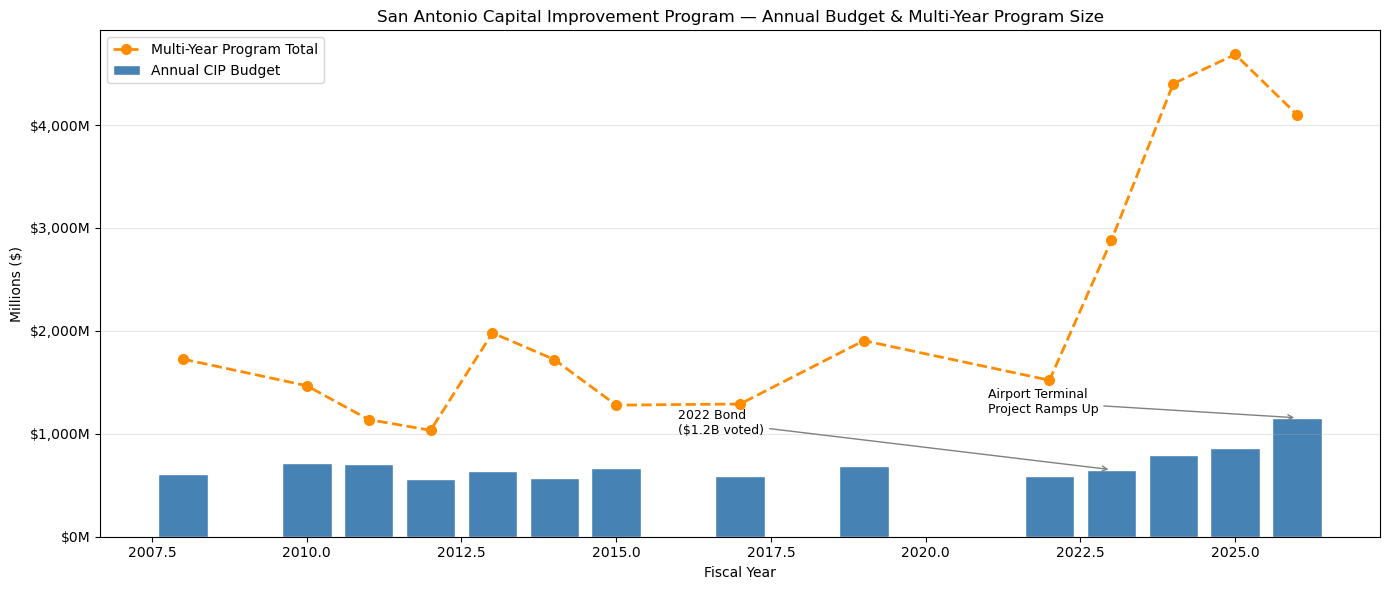


FY2008 annual CIP: $605M
FY2026 annual CIP: $1,156M
Growth: 1.9x over 18 years


In [2]:
totals = cat[cat['category'] == 'Total'].sort_values('fiscal_year')

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(totals['fiscal_year'], totals['fy_amount'] / 1e6, color='steelblue', edgecolor='white', label='Annual CIP Budget')
ax.plot(totals['fiscal_year'], totals['multiyear_amount'] / 1e6, 'o--', color='darkorange', linewidth=2,
        markersize=7, label='Multi-Year Program Total')

ax.set_xlabel('Fiscal Year')
ax.set_ylabel('Millions ($)')
ax.set_title('San Antonio Capital Improvement Program — Annual Budget & Multi-Year Program Size')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}M'))
ax.grid(axis='y', alpha=0.3)

# Annotate key events
ax.annotate('2022 Bond\n($1.2B voted)', xy=(2023, totals[totals.fiscal_year==2023]['fy_amount'].values[0]/1e6),
            xytext=(2016, 1000), fontsize=9, arrowprops=dict(arrowstyle='->', color='gray'))
ax.annotate('Airport Terminal\nProject Ramps Up', xy=(2026, totals[totals.fiscal_year==2026]['fy_amount'].values[0]/1e6),
            xytext=(2021, 1200), fontsize=9, arrowprops=dict(arrowstyle='->', color='gray'))

plt.tight_layout()
plt.show()

print(f'\nFY2008 annual CIP: ${totals.iloc[0]["fy_amount"]/1e6:,.0f}M')
print(f'FY2026 annual CIP: ${totals.iloc[-1]["fy_amount"]/1e6:,.0f}M')
print(f'Growth: {totals.iloc[-1]["fy_amount"]/totals.iloc[0]["fy_amount"]:.1f}x over {int(totals.iloc[-1]["fiscal_year"] - totals.iloc[0]["fiscal_year"])} years')

## What Is SA Building? — CIP Spending by Category Over Time

The CIP has ~10 program categories. Let's see how the mix has shifted over the years.

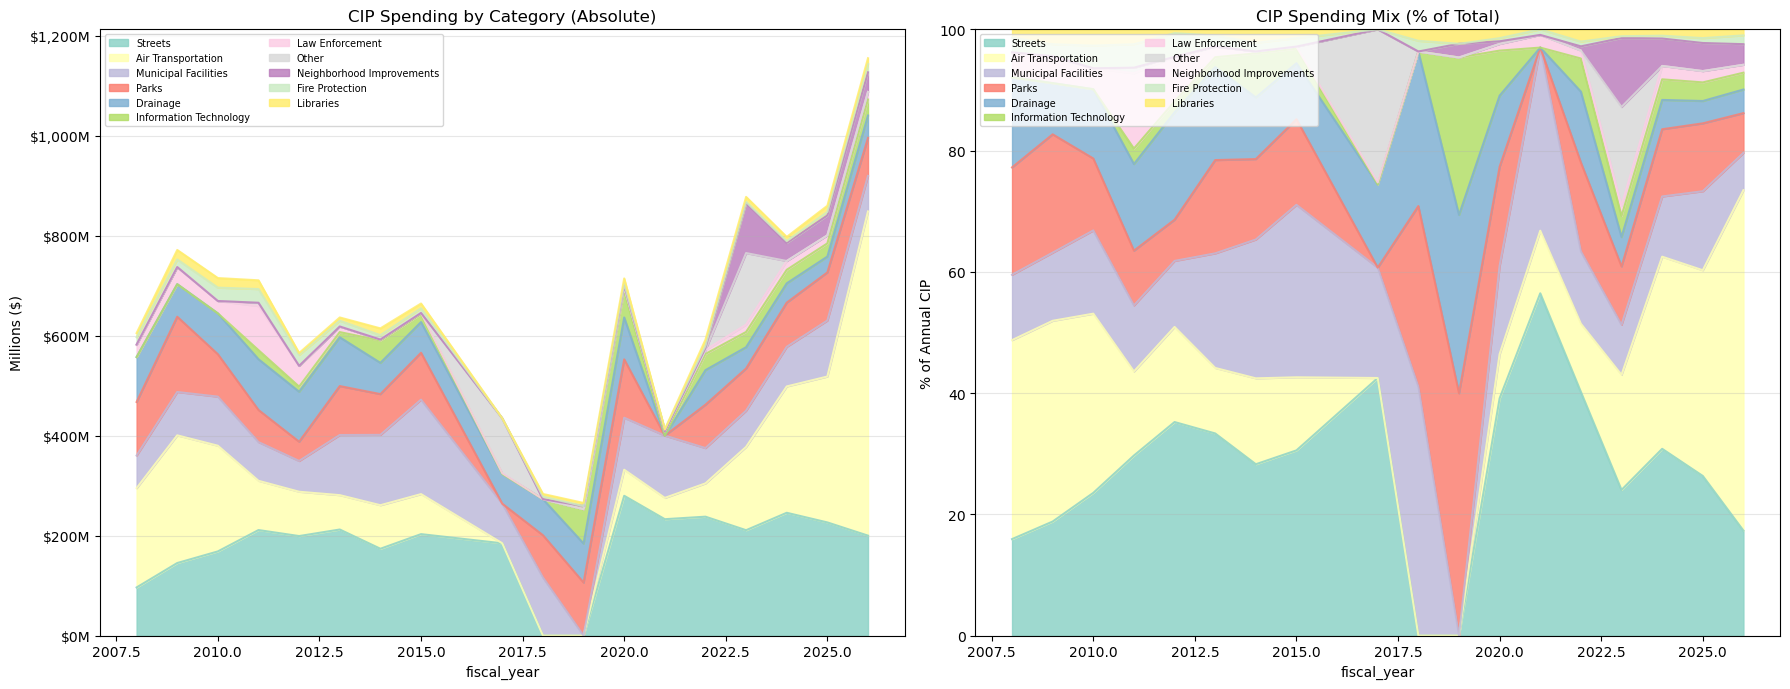

In [3]:
# Pivot: fiscal_year x category
non_total = cat[cat['category'] != 'Total'].copy()

# Normalize category names (some years have slight variations)
name_fixes = {
    'Municipal/Other Facilities': 'Municipal Facilities',
    'Other Facilities': 'Municipal Facilities',
    'Neighborhood': 'Neighborhood Improvements',
    'Streets, Bridges & Sidewalk Improvements': 'Streets',
    'Streets, Bridges & Sidewalks Improvements': 'Streets',
    'Certificates Of Obligation': 'Certificates of Obligation',
    'Other*': 'Other',
    'Other1': 'Other',
    'Community Initiatives': 'Other',
    'Aviation Funding': 'Air Transportation',
}
non_total['category'] = non_total['category'].replace(name_fixes)

# Drop revenue-source rows that got parsed as categories in some years
revenue_sources = [
    '2007 G.O. Bonds', '2012 G.O. Bonds', '2017 G.O. Bonds', '2022 G.O. Bonds',
    'Certificates of Obligation', 'Self-Supporting Certificates of Obligation',
    'Grant Funding', 'Storm Water Revenue Bonds', 'Tax Notes',
]
non_total = non_total[~non_total['category'].isin(revenue_sources)]

pivot = non_total.pivot_table(index='fiscal_year', columns='category', values='fy_amount', aggfunc='sum', fill_value=0)

# Order columns by total spend
col_order = pivot.sum().sort_values(ascending=False).index
pivot = pivot[col_order]

# Stacked area chart
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Absolute
pivot_m = pivot / 1e6
pivot_m.plot.area(ax=axes[0], colormap='Set3', alpha=0.85)
axes[0].set_title('CIP Spending by Category (Absolute)')
axes[0].set_ylabel('Millions ($)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}M'))
axes[0].legend(loc='upper left', fontsize=7, ncol=2)
axes[0].grid(axis='y', alpha=0.3)

# Percentage
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
pivot_pct.plot.area(ax=axes[1], colormap='Set3', alpha=0.85)
axes[1].set_title('CIP Spending Mix (% of Total)')
axes[1].set_ylabel('% of Annual CIP')
axes[1].set_ylim(0, 100)
axes[1].legend(loc='upper left', fontsize=7, ncol=2)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## The Airport Story

Air Transportation spending is the elephant in the room — it's the new SA International Airport terminal.
Let's isolate it to see the rest of the CIP more clearly.

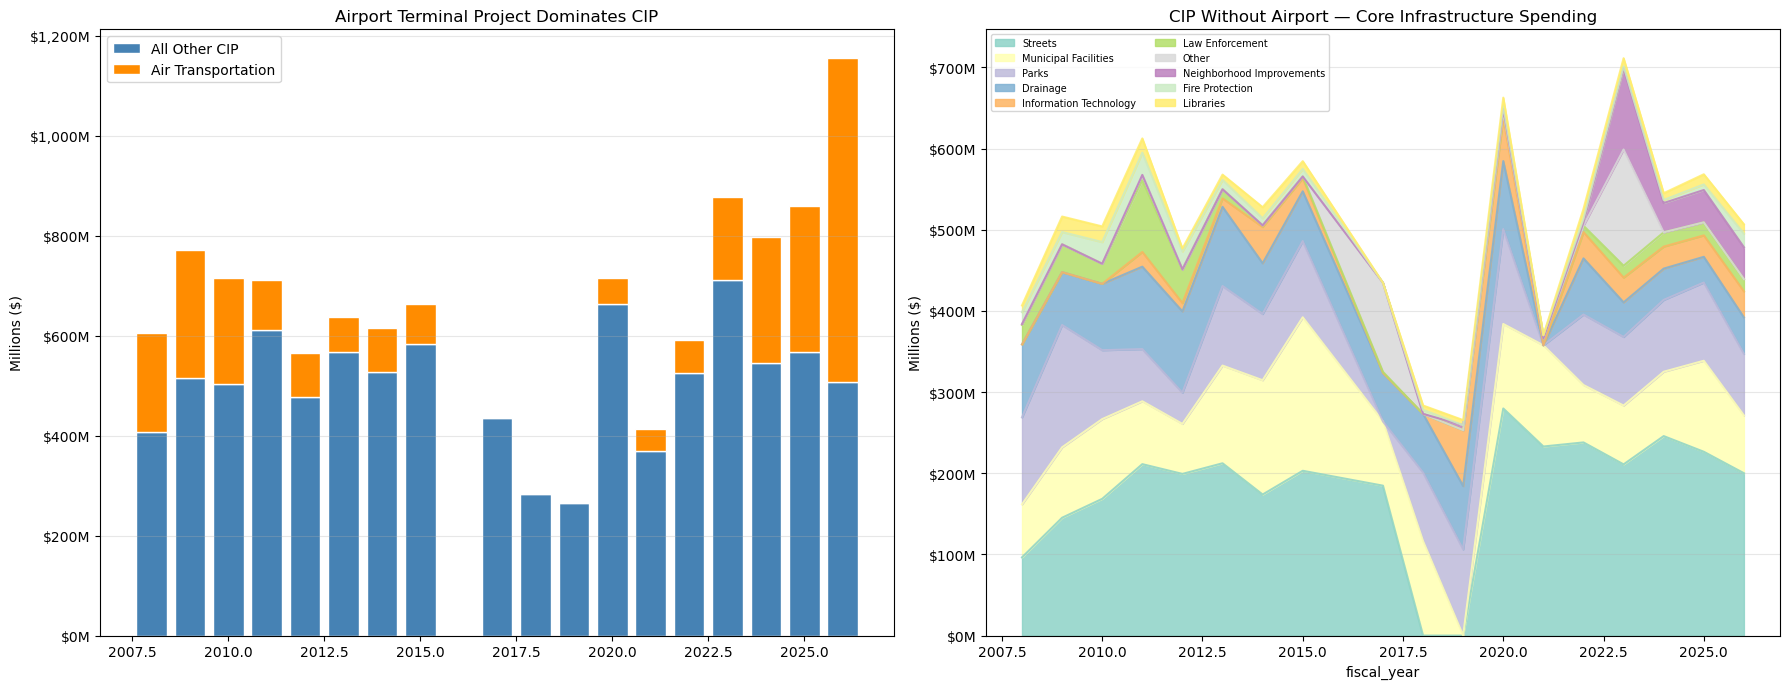

Airport share of FY2026 CIP: 56%


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: Airport vs everything else
airport = pivot.get('Air Transportation', pd.Series(0, index=pivot.index)) / 1e6
non_airport = (pivot.sum(axis=1) - pivot.get('Air Transportation', 0)) / 1e6

axes[0].bar(pivot.index, non_airport, color='steelblue', edgecolor='white', label='All Other CIP')
axes[0].bar(pivot.index, airport, bottom=non_airport, color='darkorange', edgecolor='white', label='Air Transportation')
axes[0].set_title('Airport Terminal Project Dominates CIP')
axes[0].set_ylabel('Millions ($)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}M'))
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Right: CIP without airport
no_airport = pivot.drop(columns=['Air Transportation'], errors='ignore') / 1e6
no_airport.plot.area(ax=axes[1], colormap='Set3', alpha=0.85)
axes[1].set_title('CIP Without Airport — Core Infrastructure Spending')
axes[1].set_ylabel('Millions ($)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}M'))
axes[1].legend(loc='upper left', fontsize=7, ncol=2)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Airport share of FY2026 CIP: {airport.get(2026, 0) / (airport.get(2026, 0) + non_airport.get(2026, 1)):.0%}')

## How Is It All Funded? — CIP Revenue Sources

Capital spending comes from G.O. Bonds (voter-approved), Certificates of Obligation (council-issued),
Tax Notes, Airport revenue, grants, and other sources.

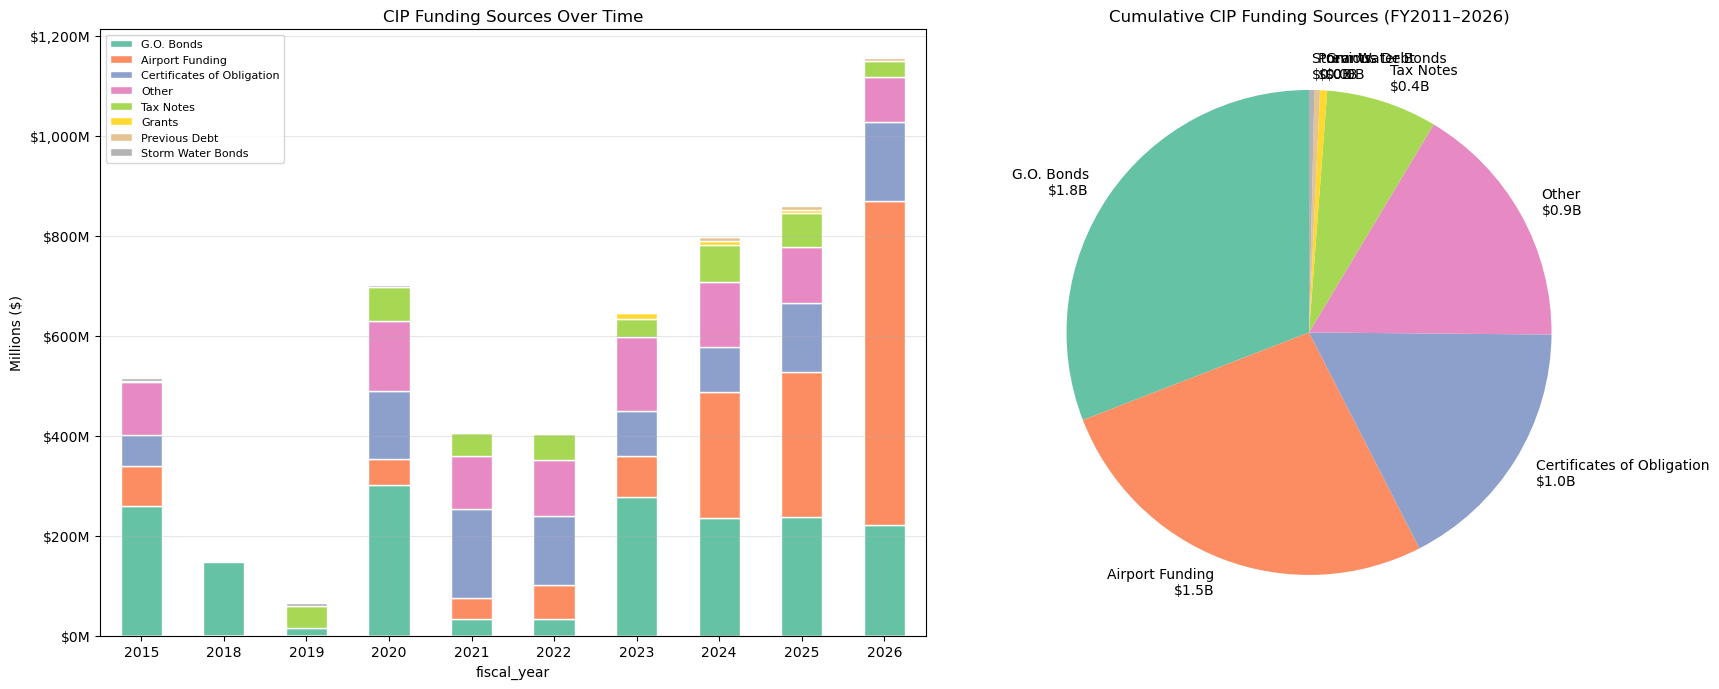

In [5]:
rev_non_total = rev[rev['source'] != 'Total'].copy()

# Group smaller sources
def simplify_source(s):
    s_lower = s.lower()
    if 'g.o. bond' in s_lower or 'general obligation' in s_lower:
        return 'G.O. Bonds'
    elif 'certificate' in s_lower:
        return 'Certificates of Obligation'
    elif 'airport' in s_lower or 'aviation' in s_lower:
        return 'Airport Funding'
    elif 'tax note' in s_lower:
        return 'Tax Notes'
    elif 'grant' in s_lower:
        return 'Grants'
    elif 'storm' in s_lower:
        return 'Storm Water Bonds'
    elif 'previous' in s_lower:
        return 'Previous Debt'
    else:
        return 'Other'

rev_non_total['source_group'] = rev_non_total['source'].apply(simplify_source)

rev_pivot = rev_non_total.pivot_table(index='fiscal_year', columns='source_group',
                                       values='fy_amount', aggfunc='sum', fill_value=0)

# Order by total
rev_pivot = rev_pivot[rev_pivot.sum().sort_values(ascending=False).index]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Stacked bar
(rev_pivot / 1e6).plot.bar(stacked=True, ax=axes[0], colormap='Set2', edgecolor='white')
axes[0].set_title('CIP Funding Sources Over Time')
axes[0].set_ylabel('Millions ($)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}M'))
axes[0].legend(fontsize=8)
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(axis='y', alpha=0.3)

# Cumulative pie for all years combined
source_totals = rev_non_total.groupby('source_group')['fy_amount'].sum().sort_values(ascending=False)
colors = plt.cm.Set2(np.linspace(0, 1, len(source_totals)))
axes[1].pie(source_totals, labels=[f'{s}\n${v/1e9:.1f}B' for s, v in source_totals.items()],
            colors=colors, startangle=90)
axes[1].set_title(f'Cumulative CIP Funding Sources (FY{rev.fiscal_year.min()}–{rev.fiscal_year.max()})')

plt.tight_layout()
plt.show()

## Bond Programs — SA's Three Big Bond Cycles

San Antonio voters have approved three major G.O. Bond programs:
- **2012 Bonds**: $596M
- **2017 Bonds**: $850M
- **2022 Bonds**: $1.2B (largest in city history)

Each year's budget reports how much has been issued vs. what remains. Let's track that drawdown.

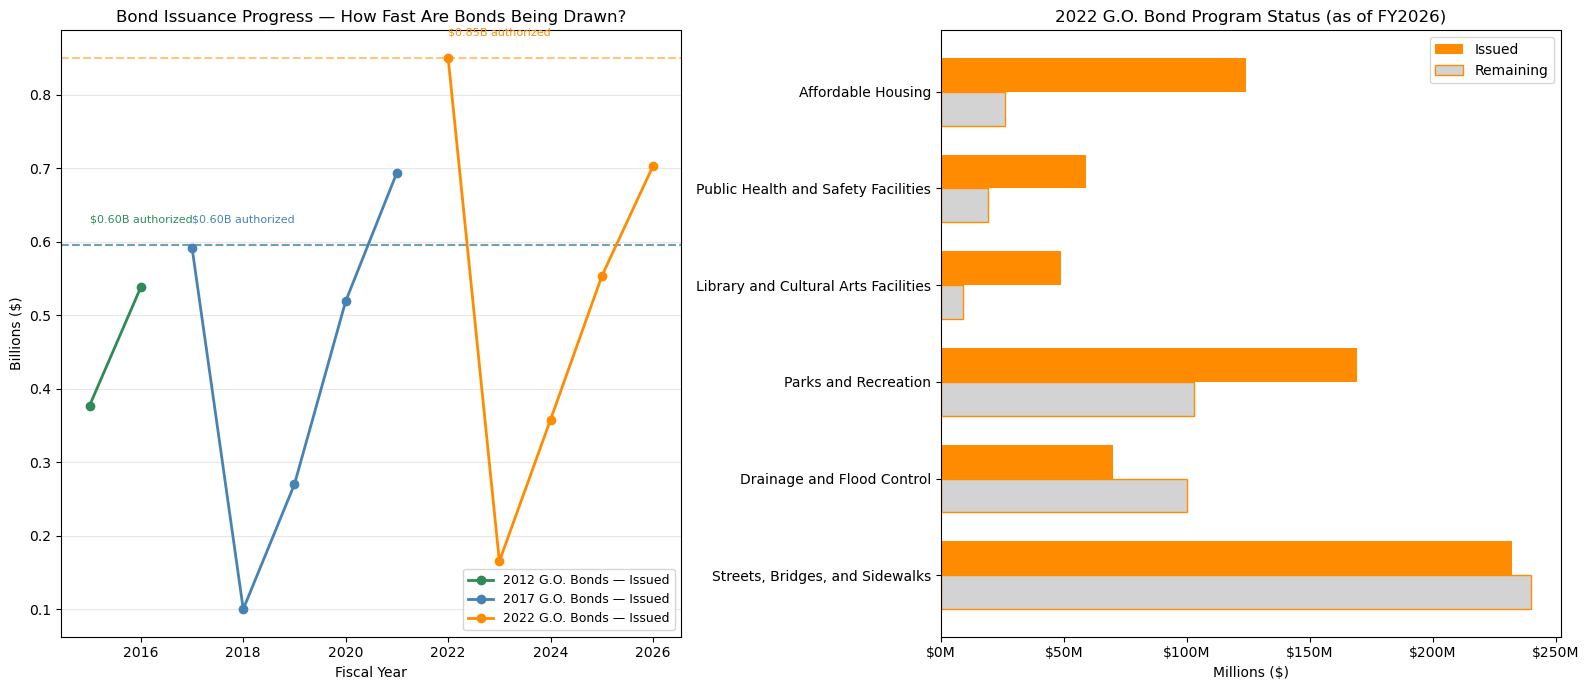

2012 G.O. Bonds: $0.60B authorized | $0.54B issued (90%) | $0.05B remaining
2017 G.O. Bonds: $0.85B authorized | $0.69B issued (82%) | $0.16B remaining
2022 G.O. Bonds: $1.20B authorized | $0.70B issued (59%) | $0.50B remaining


In [6]:
bond_totals = bonds[bonds['proposition'] == 'Total'].copy()
bond_props = bonds[bonds['proposition'] != 'Total'].copy()

programs = bond_totals['bond_program'].unique()
colors_map = {'2012 G.O. Bonds': 'seagreen', '2017 G.O. Bonds': 'steelblue', '2022 G.O. Bonds': 'darkorange'}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Drawdown over time (issued vs authorized)
for prog in sorted(programs):
    subset = bond_totals[bond_totals['bond_program'] == prog].sort_values('fiscal_year')
    color = colors_map.get(prog, 'gray')
    axes[0].plot(subset['fiscal_year'], subset['issued'] / 1e9, 'o-', color=color, linewidth=2,
                 markersize=6, label=f'{prog} — Issued')
    axes[0].axhline(y=subset['authorized'].iloc[0] / 1e9, color=color, linestyle='--', alpha=0.5)
    axes[0].text(subset['fiscal_year'].iloc[0], subset['authorized'].iloc[0] / 1e9 + 0.03,
                 f'${subset["authorized"].iloc[0]/1e9:.2f}B authorized', fontsize=8, color=color)

axes[0].set_title('Bond Issuance Progress — How Fast Are Bonds Being Drawn?')
axes[0].set_ylabel('Billions ($)')
axes[0].set_xlabel('Fiscal Year')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# Right: Latest status by proposition (2022 bonds)
latest_fy = bond_props[bond_props['bond_program'] == '2022 G.O. Bonds']['fiscal_year'].max()
latest_2022 = bond_props[(bond_props['bond_program'] == '2022 G.O. Bonds') &
                          (bond_props['fiscal_year'] == latest_fy)].copy()

if not latest_2022.empty:
    y = range(len(latest_2022))
    h = 0.35
    axes[1].barh([i + h/2 for i in y], latest_2022['issued'] / 1e6, h,
                 label='Issued', color='darkorange')
    axes[1].barh([i - h/2 for i in y], latest_2022['unissued'] / 1e6, h,
                 label='Remaining', color='lightgray', edgecolor='darkorange')
    axes[1].set_yticks(list(y))
    axes[1].set_yticklabels(latest_2022['proposition'].values)
    axes[1].set_xlabel('Millions ($)')
    axes[1].set_title(f'2022 G.O. Bond Program Status (as of FY{int(latest_fy)})')
    axes[1].legend()
    axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}M'))

plt.tight_layout()
plt.show()

# Print summary
for prog in sorted(programs):
    latest = bond_totals[bond_totals['bond_program'] == prog].sort_values('fiscal_year').iloc[-1]
    pct = latest['issued'] / latest['authorized'] * 100
    print(f"{prog}: ${latest['authorized']/1e9:.2f}B authorized | "
          f"${latest['issued']/1e9:.2f}B issued ({pct:.0f}%) | "
          f"${latest['unissued']/1e9:.2f}B remaining")

## CIP vs. Disbursements — Closing the Loop

Now we can finally answer the question from the disbursement analysis:
*Why did Streets & Infrastructure disbursements ($614M) blow past the operating budget ($196M)?*

Because the CIP budget for Streets alone was **$226M** in FY2025, funded by bond proceeds
and certificates of obligation — completely separate from the operating budget.

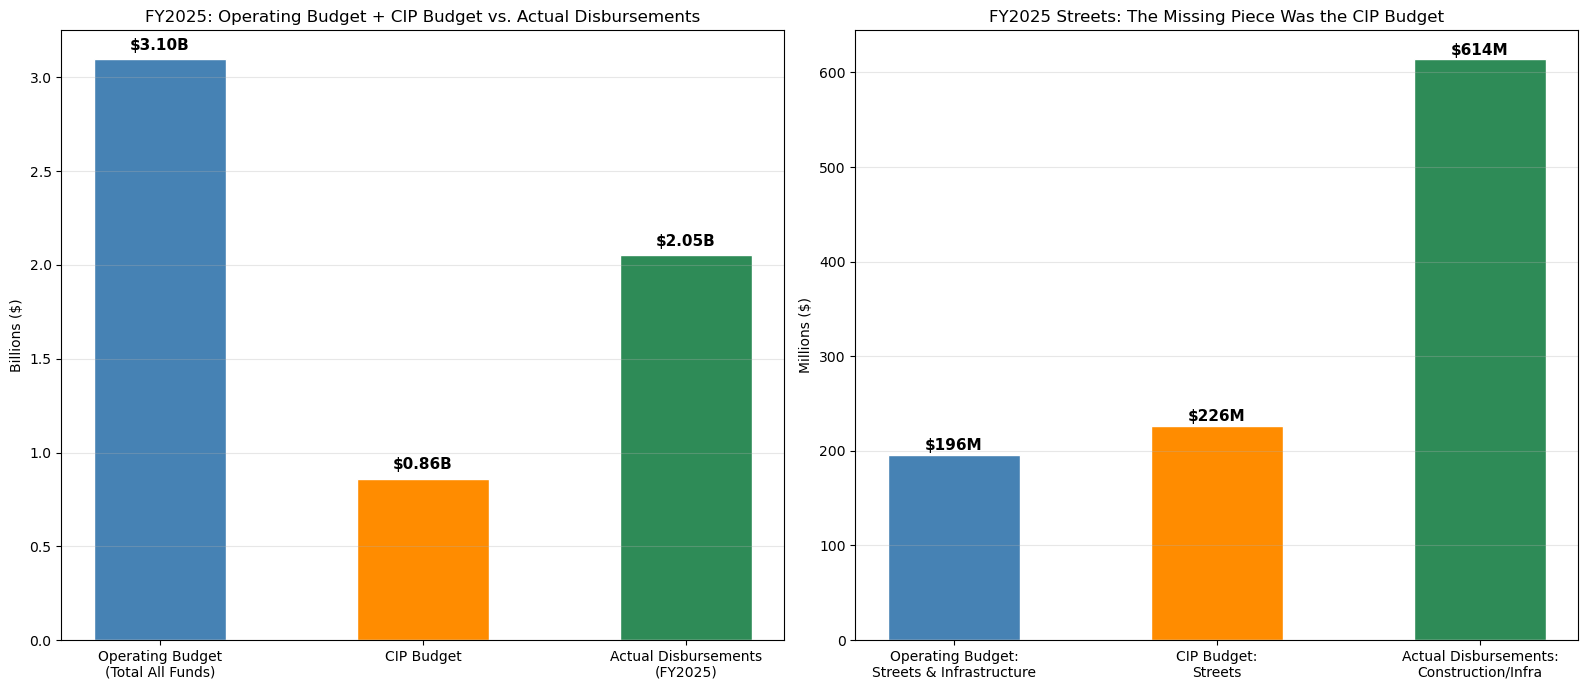

Operating budget (Streets):  $     196M
CIP budget (Streets):        $     226M
Combined:                    $     423M
Actual disbursed:            $     614M

The CIP explains the gap — operating + CIP = $423M vs $614M disbursed


In [7]:
# Load disbursement data for FY2025
disb = pd.read_csv('../data/raw/Check Disbursements_03_10_2026.csv', skiprows=1)
disb['Payment Amount'] = pd.to_numeric(disb['Payment Amount'], errors='coerce')
disb_fy25 = disb[disb['FiscalYear'] == 2025]

# Load operating budget
budget = pd.read_csv('../data/processed/combined_budget_summary.csv')
skip_prefixes = ['TOTAL APPROPRIATIONS', 'Subtotal Appropriations', 'GROSS ENDING',
                 'Reserve for', 'Reserves for', 'Financial Reserves',
                 'Transfers to', 'Amendments', '1 The total']
op_budget_fy25 = budget[
    (budget['section'] == 'appropriation') &
    (budget['fund'] == 'Total All Funds') &
    (budget['fiscal_year'] == 2025) &
    (~budget['line_item'].str.startswith(tuple(skip_prefixes)))
]

# CIP budget for FY2025
cip_fy25 = cat[(cat['fiscal_year'] == 2025) & (cat['category'] != 'Total')]

# Build the comparison
op_total = op_budget_fy25['amount'].sum()
cip_total = cip_fy25['fy_amount'].sum()
disb_total = disb_fy25['Payment Amount'].sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: The three budget pools
bars = axes[0].bar(['Operating Budget\n(Total All Funds)', 'CIP Budget', 'Actual Disbursements\n(FY2025)'],
                    [op_total / 1e9, cip_total / 1e9, disb_total / 1e9],
                    color=['steelblue', 'darkorange', 'seagreen'], edgecolor='white', width=0.5)
axes[0].set_ylabel('Billions ($)')
axes[0].set_title('FY2025: Operating Budget + CIP Budget vs. Actual Disbursements')
for bar, val in zip(bars, [op_total, cip_total, disb_total]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'${val/1e9:.2f}B', ha='center', fontsize=11, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Right: Streets comparison specifically
streets_op = op_budget_fy25[op_budget_fy25['line_item'].str.contains('Streets', case=False)]['amount'].sum()
streets_cip = cip_fy25[cip_fy25['category'] == 'Streets']['fy_amount'].sum()
# Streets disbursements (Construction Cost + Engineering + Building Improvements + CAPITAL PROGRAMS + Paving)
streets_kw = ['Construction Cost', 'Paving', 'Engineering Fees', 'CAPITAL PROGRAMS',
              'Building and Improvements', 'Streets', 'Traffic', 'Drainage']
streets_disb = disb_fy25[disb_fy25['Service'].apply(
    lambda s: any(kw.lower() in s.lower() for kw in streets_kw))
]['Payment Amount'].sum()

x = ['Operating Budget:\nStreets & Infrastructure', 'CIP Budget:\nStreets', 'Actual Disbursements:\nConstruction/Infra']
vals = [streets_op / 1e6, streets_cip / 1e6, streets_disb / 1e6]
bars2 = axes[1].bar(x, vals, color=['steelblue', 'darkorange', 'seagreen'], edgecolor='white', width=0.5)
axes[1].set_ylabel('Millions ($)')
axes[1].set_title('FY2025 Streets: The Missing Piece Was the CIP Budget')
for bar, val in zip(bars2, vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'${val:,.0f}M', ha='center', fontsize=11, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Operating budget (Streets):  ${streets_op/1e6:>8,.0f}M')
print(f'CIP budget (Streets):        ${streets_cip/1e6:>8,.0f}M')
print(f'Combined:                    ${(streets_op + streets_cip)/1e6:>8,.0f}M')
print(f'Actual disbursed:            ${streets_disb/1e6:>8,.0f}M')
print(f'\nThe CIP explains the gap — operating + CIP = ${(streets_op + streets_cip)/1e6:,.0f}M vs ${streets_disb/1e6:,.0f}M disbursed')

## Key Takeaways

1. **SA's capital program has nearly doubled** from ~$600M/year (FY2008) to $1.16B (FY2026),
   driven primarily by the new airport terminal ($2.4B over 6 years).

2. **Without the airport, core infrastructure spending is still growing** — Streets, Parks, and Drainage
   together represent the bulk of non-aviation CIP spending.

3. **Bond programs are getting bigger**: $596M (2012) → $850M (2017) → $1.2B (2022).
   The 2022 bonds still have ~$500M unissued, meaning more construction spending is coming.

4. **The CIP solves the disbursement mystery**: Construction disbursements appeared to "blow past"
   the operating budget because they're funded by the CIP (bonds + certificates), which is a
   completely separate funding pool from the operating budget.

5. **Certificates of Obligation are a growing share** of capital funding — these don't require voter
   approval (only City Council), which is worth tracking from a governance perspective.